Dataset from kaggle: https://www.kaggle.com/datasets/ziya07/operational-conveyor-fault-dataset 

## 1. Problem statement

This project focuses on the multiclass classification of conveyor fault types using sensor-based operational data. The main objective is to determine whether machine-learning models can reliably distinguish among different fault categories from a small set of numerical features related to speed, load, temperature, vibration, and current. In addition to predictive performance, the analysis also aims to identify the most informative variables, assess the usefulness of dimensionality reduction, and compare the behavior of different modeling approaches in terms of both accuracy and interpretability.

In [3]:
# Import general libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Import data as DataFrame
data = pd.read_csv('../data/conveyor_fault_dataset.csv')
data.head()

,Fault,Speed (rpm),Load (kg),Temperature (℃),Vibration (m/s²),Current (A)
0,ball bearing,116,490,43,0.82,3.17
1,ball bearing,121,507,43,0.83,3.09
2,ball bearing,116,495,38,0.68,3.29
3,ball bearing,116,491,43,0.77,3.19
4,ball bearing,119,492,43,0.75,3.23


In [5]:
# Rename columns for better readability and consistency
data.rename(columns={'Fault': 'fault',
                     'Speed (rpm)':'speed_rpm', 
                     'Load (kg)':'load_kg', 
                     'Temperature (℃)':'temperature_c', 
                     'Vibration (m/s²)':'vibration_ms2', 
                     'Current (A)': 'current_a'}, inplace=True)
data.columns

Index(['fault', 'speed_rpm', 'load_kg', 'temperature_c', 'vibration_ms2',
       'current_a'],
      dtype='object')

## 2. Exploratory data analysis

The exploratory analysis is intended to understand the structure and quality of the dataset before model development. This stage examines class balance, descriptive statistics, variable distributions, and the presence of outliers or unusual patterns. It also provides an initial understanding of how the different fault types behave across the available sensor variables. These first insights are useful to assess whether the dataset contains meaningful class-dependent structure and to anticipate possible challenges such as overlap between fault categories.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fault          1209 non-null   object 
 1   speed_rpm      1209 non-null   int64  
 2   load_kg        1209 non-null   int64  
 3   temperature_c  1209 non-null   int64  
 4   vibration_ms2  1209 non-null   float64
 5   current_a      1209 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 56.8+ KB


The dataset contains 1,209 observations and five numerical sensor-related features, with fault type as the target variable. Since no missing values were found, the data quality can be considered satisfactory from the outset. In addition, the dataset is relatively compact and structured, which makes it suitable for both exploratory analysis and supervised classification without requiring complex cleaning procedures.

In [7]:
# Types of faults
data['fault'].value_counts()

fault
belt slippage         204
ball bearing          201
central shaft         201
pulley                201
drive motor           201
idler roller fault    201
Name: count, dtype: int64

The fault classes are almost perfectly balanced, with approximately the same number of observations for each category. This is an important advantage because it reduces the risk of biased learning toward majority classes and allows model performance to be interpreted more reliably. As a result, overall accuracy becomes a meaningful metric, although class-wise metrics remain essential to identify specific weaknesses.Different types ara evenly represented in the dataset with almost the same amount of entries each one.

In [8]:
# Summary statistics per fault type
features = ['speed_rpm', 'load_kg', 'temperature_c', 'vibration_ms2', 'current_a']

feature_labels = {
    'speed_rpm': 'Speed (rpm)',
    'load_kg': 'Load (kg)',
    'temperature_c': 'Temperature (°C)',
    'vibration_ms2': 'Vibration (m/s²)',
    'current_a': 'Current (A)'
}

grouped_stats = data.groupby('fault')[features].agg(['mean', 'std', 'min', 'max']).round(2)
grouped_stats = grouped_stats.rename(columns=feature_labels, level=0)
grouped_stats.columns.names = ['Feature', 'Statistic']

display(grouped_stats)

Feature            Speed (rpm)                 Load (kg)                  \
Statistic                 mean   std  min  max      mean   std  min  max   
fault                                                                      
ball bearing            120.19  3.07  115  125    494.92  8.60  480  510   
belt slippage           114.75  3.17  110  120    480.74  6.34  470  490   
central shaft           124.71  3.07  120  130    515.29  8.42  500  530   
drive motor             124.91  3.12  120  130    535.13  8.82  520  550   
idler roller fault      119.92  3.28  115  125    510.07  6.41  500  520   
pulley                  119.93  3.17  115  125    504.98  5.83  495  515   

Feature            Temperature (°C)               Vibration (m/s²)        \
Statistic                      mean   std min max             mean   std   
fault                                                                      
ball bearing                  39.89  2.05  37  43             0.75  0.06   
belt slippage                 37.68  1.73  35  40             0.75  0.03   
central shaft                 44.17  2.03  41  47             0.90  0.06   
drive motor                   45.76  1.70  43  48             1.10  0.06   
idler roller fault            42.16  1.36  40  44             0.85  0.03   
pulley                        39.95  1.45  38  42             0.81  0.06   

Feature                        Current (A)                  
Statistic            min   max        mean   std  min  max  
fault                                                       
ball bearing        0.65  0.84        3.21  0.12  3.0  3.4  
belt slippage       0.70  0.80        3.20  0.06  3.1  3.3  
central shaft       0.80  1.00        3.59  0.11  3.4  3.8  
drive motor         1.00  1.20        3.80  0.12  3.6  4.0  
idler roller fault  0.80  0.90        3.40  0.06  3.3  3.5  
pulley              0.70  0.90        3.40  0.12  3.2  3.6

The descriptive statistics show that each fault type has a distinct operational profile rather than a random pattern. In particular, drive motor and central shaft faults present the highest mean values in current, load, temperature, and vibration, suggesting more severe operating conditions, whereas belt slippage tends to show the lowest values in most variables. By contrast, ball bearing, idler roller fault, and pulley display more intermediate and partially overlapping ranges. Overall, these results confirm that the dataset contains structured differences between fault categories, which supports its suitability for classification tasks.

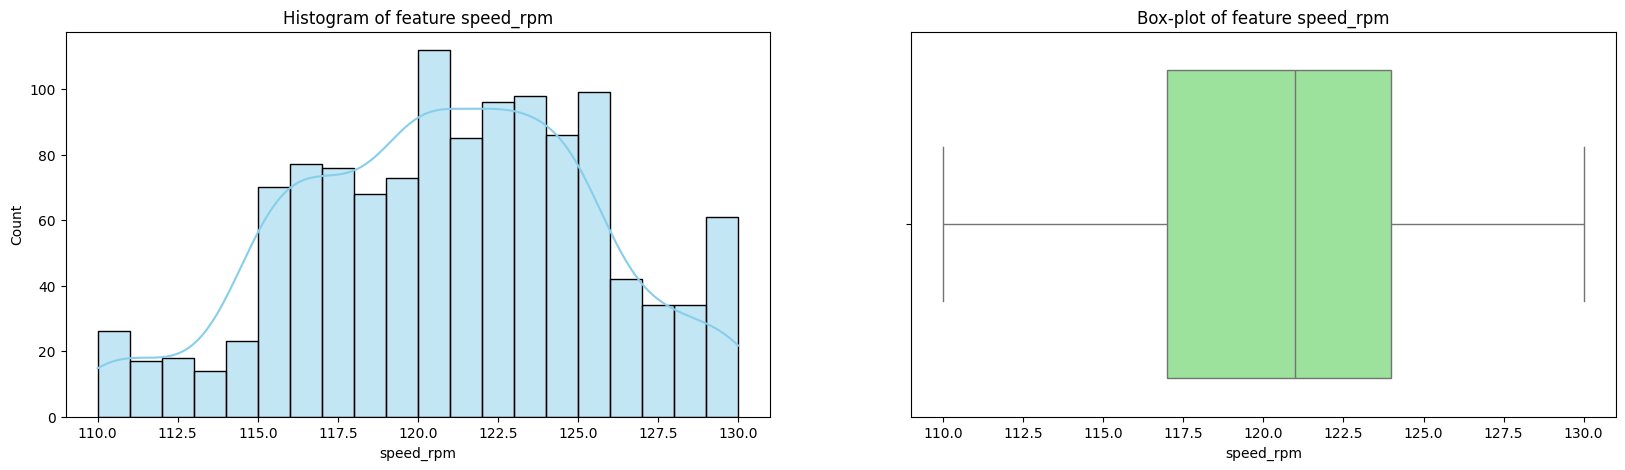

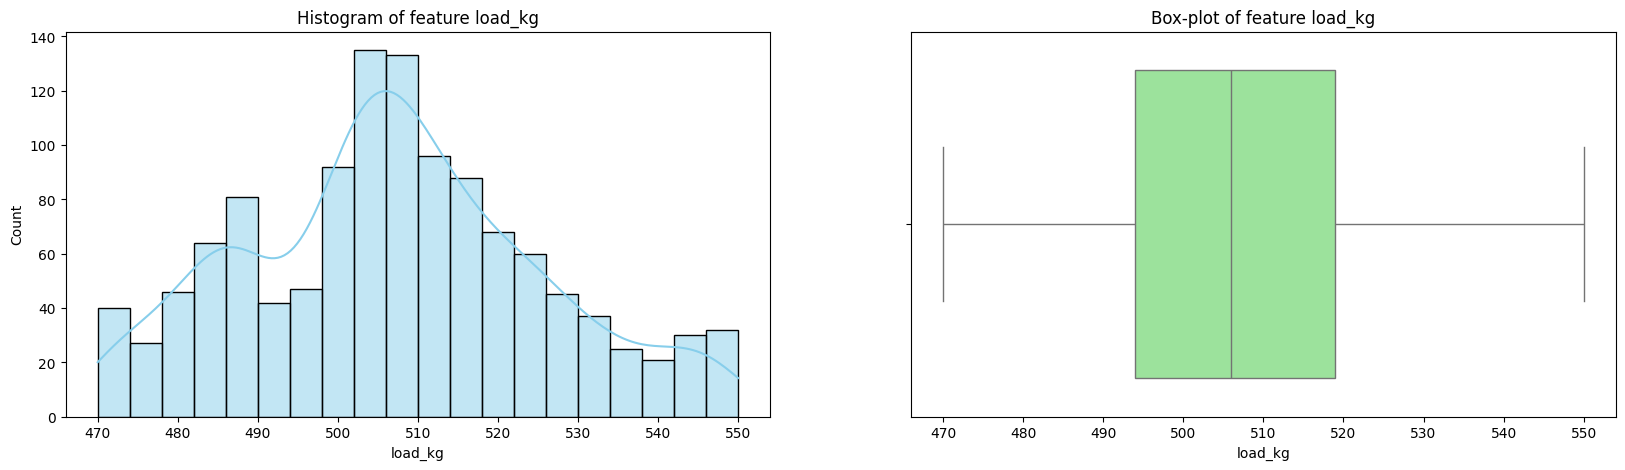

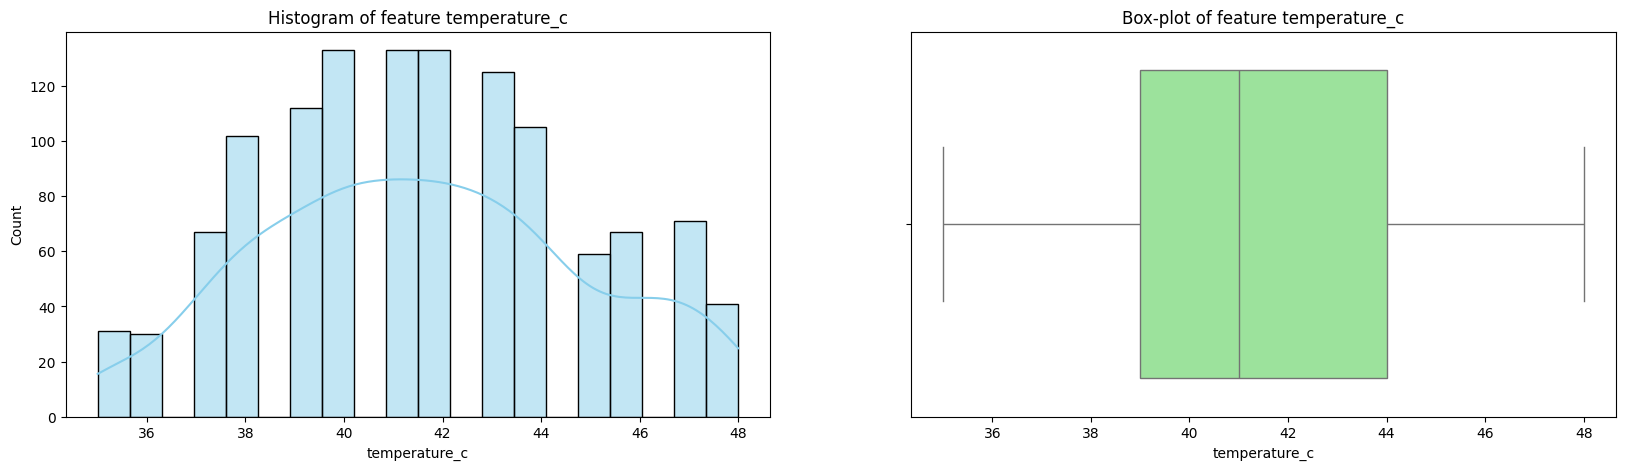

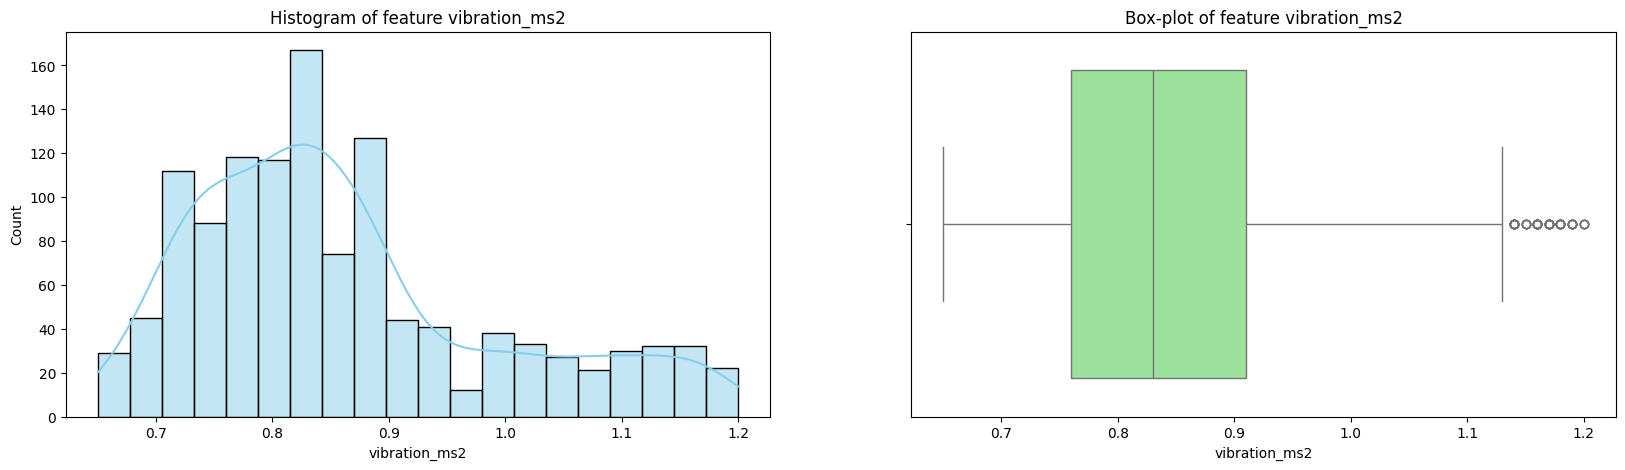

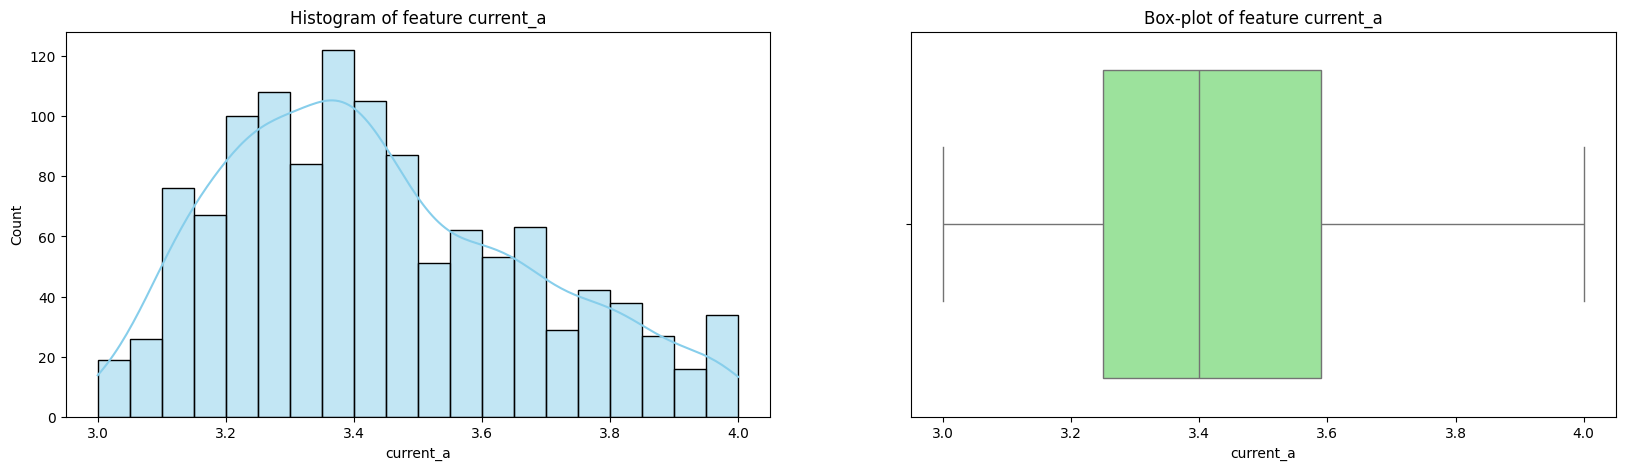

In [9]:
#Plotting Histograms and Box-plots of features
def feature_plots(data):
    X = data.drop('fault', axis=1)
    features = X.columns

    for col in features:
        plt.figure(figsize=(20,5))

        plt.subplot(1,2,1)
        sns.histplot(X[col], bins=20, kde=True, color='skyblue')
        plt.title(f'Histogram of feature {col}')
        plt.xlabel(col)

        plt.subplot(1,2,2)
        sns.boxplot(X[col], color='lightgreen', orient='h')
        plt.title(f'Box-plot of feature {col}')
        plt.xlabel(col)

        plt.show()

feature_plots(data)        

In [10]:
# Outlier detection using IQR method
outlier_summary = []

for col in features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    
    outlier_summary.append({
        'Variable': col,
        'Outliers': n_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

        Variable  Outliers
0      speed_rpm         0
1        load_kg         0
2  temperature_c         0
3  vibration_ms2        66
4      current_a         0


The individual feature distributions are generally well behaved, with no major irregularities in most variables. Speed, load, temperature, and current do not exhibit problematic outliers, whereas vibration presents a noticeable number of extreme values. However, given the industrial context, these vibration outliers are likely to reflect meaningful fault-related behavior rather than measurement errors. Therefore, they should not automatically be treated as anomalies to remove, since they may carry useful information for classification.

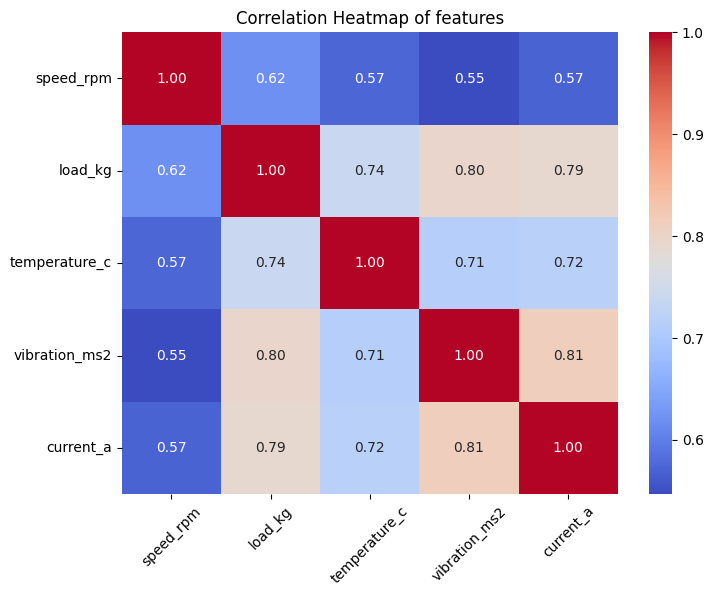

In [11]:
# Plotting correlation heatmap
corr = data.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.xticks(rotation=45)
plt.title('Correlation Heatmap of features')
plt.show()

The correlation matrix reveals strong positive relationships among several sensor variables, especially between vibration and current, and also between load, vibration, temperature, and current. This indicates that the variables are not independent and may be capturing related physical effects of machine degradation. From a modeling perspective, this confirms the existence of some redundancy in the feature space, which helps explain why dimensionality reduction techniques such as PCA can summarize a large portion of the variance.

In [12]:
# ANOVA test for each feature across fault types
from scipy.stats import f_oneway
import pandas as pd

anova_results = []

for col in features:
    groups = [group[col].values for _, group in data.groupby('fault')]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append({
        'Variable': col,
        'F-statistic': f_stat,
        'p-value': p_value
    })

anova_df = pd.DataFrame(anova_results).sort_values(by='F-statistic', ascending=False)
print(anova_df)

        Variable  F-statistic        p-value
3  vibration_ms2  1374.319272   0.000000e+00
1        load_kg  1228.074856   0.000000e+00
4      current_a  1040.152514   0.000000e+00
2  temperature_c   605.144728   0.000000e+00
0      speed_rpm   288.194732  8.793965e-203


The ANOVA results indicate that all variables differ significantly across fault categories, as reflected by the extremely small p-values. Among them, vibration shows the highest discriminative power, followed by load and current, while temperature also contributes meaningfully to class separation. In contrast, speed appears to be the least discriminative variable, although it remains statistically significant. Overall, these results confirm that the dataset contains strong feature-level differences between fault types.

<Figure size 1500x1000 with 0 Axes>

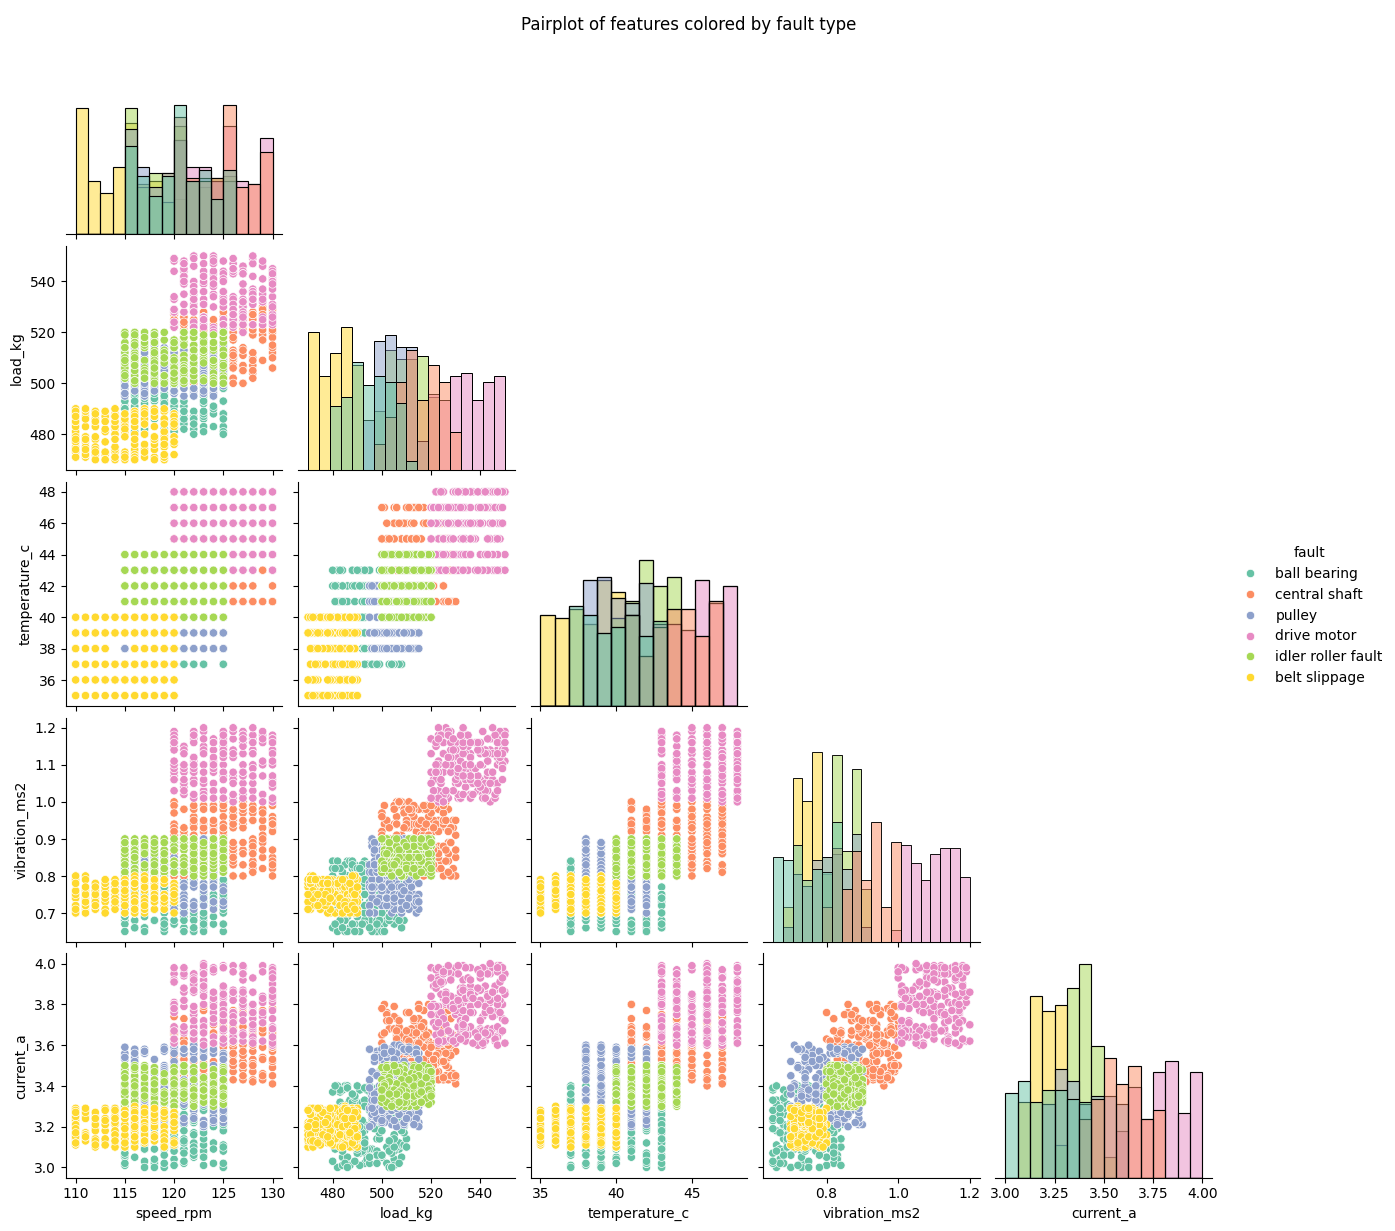

In [13]:
# Scatter plots of features colored by fault type
plt.figure(figsize=(15,10))

sns.pairplot(data, hue='fault', corner=True, diag_kind='hist', palette='Set2')
plt.suptitle('Pairplot of features colored by fault type')
plt.show()

The multivariate visualizations show that the dataset contains meaningful class structure, although the degree of separation varies across fault types. Some faults, such as drive motor and belt slippage, appear relatively well separated, whereas others, especially pulley and ball bearing faults, exhibit more overlap. This suggests that the problem is learnable but not trivial, and that classification errors are likely to concentrate in classes whose operational signatures are closer to each other.

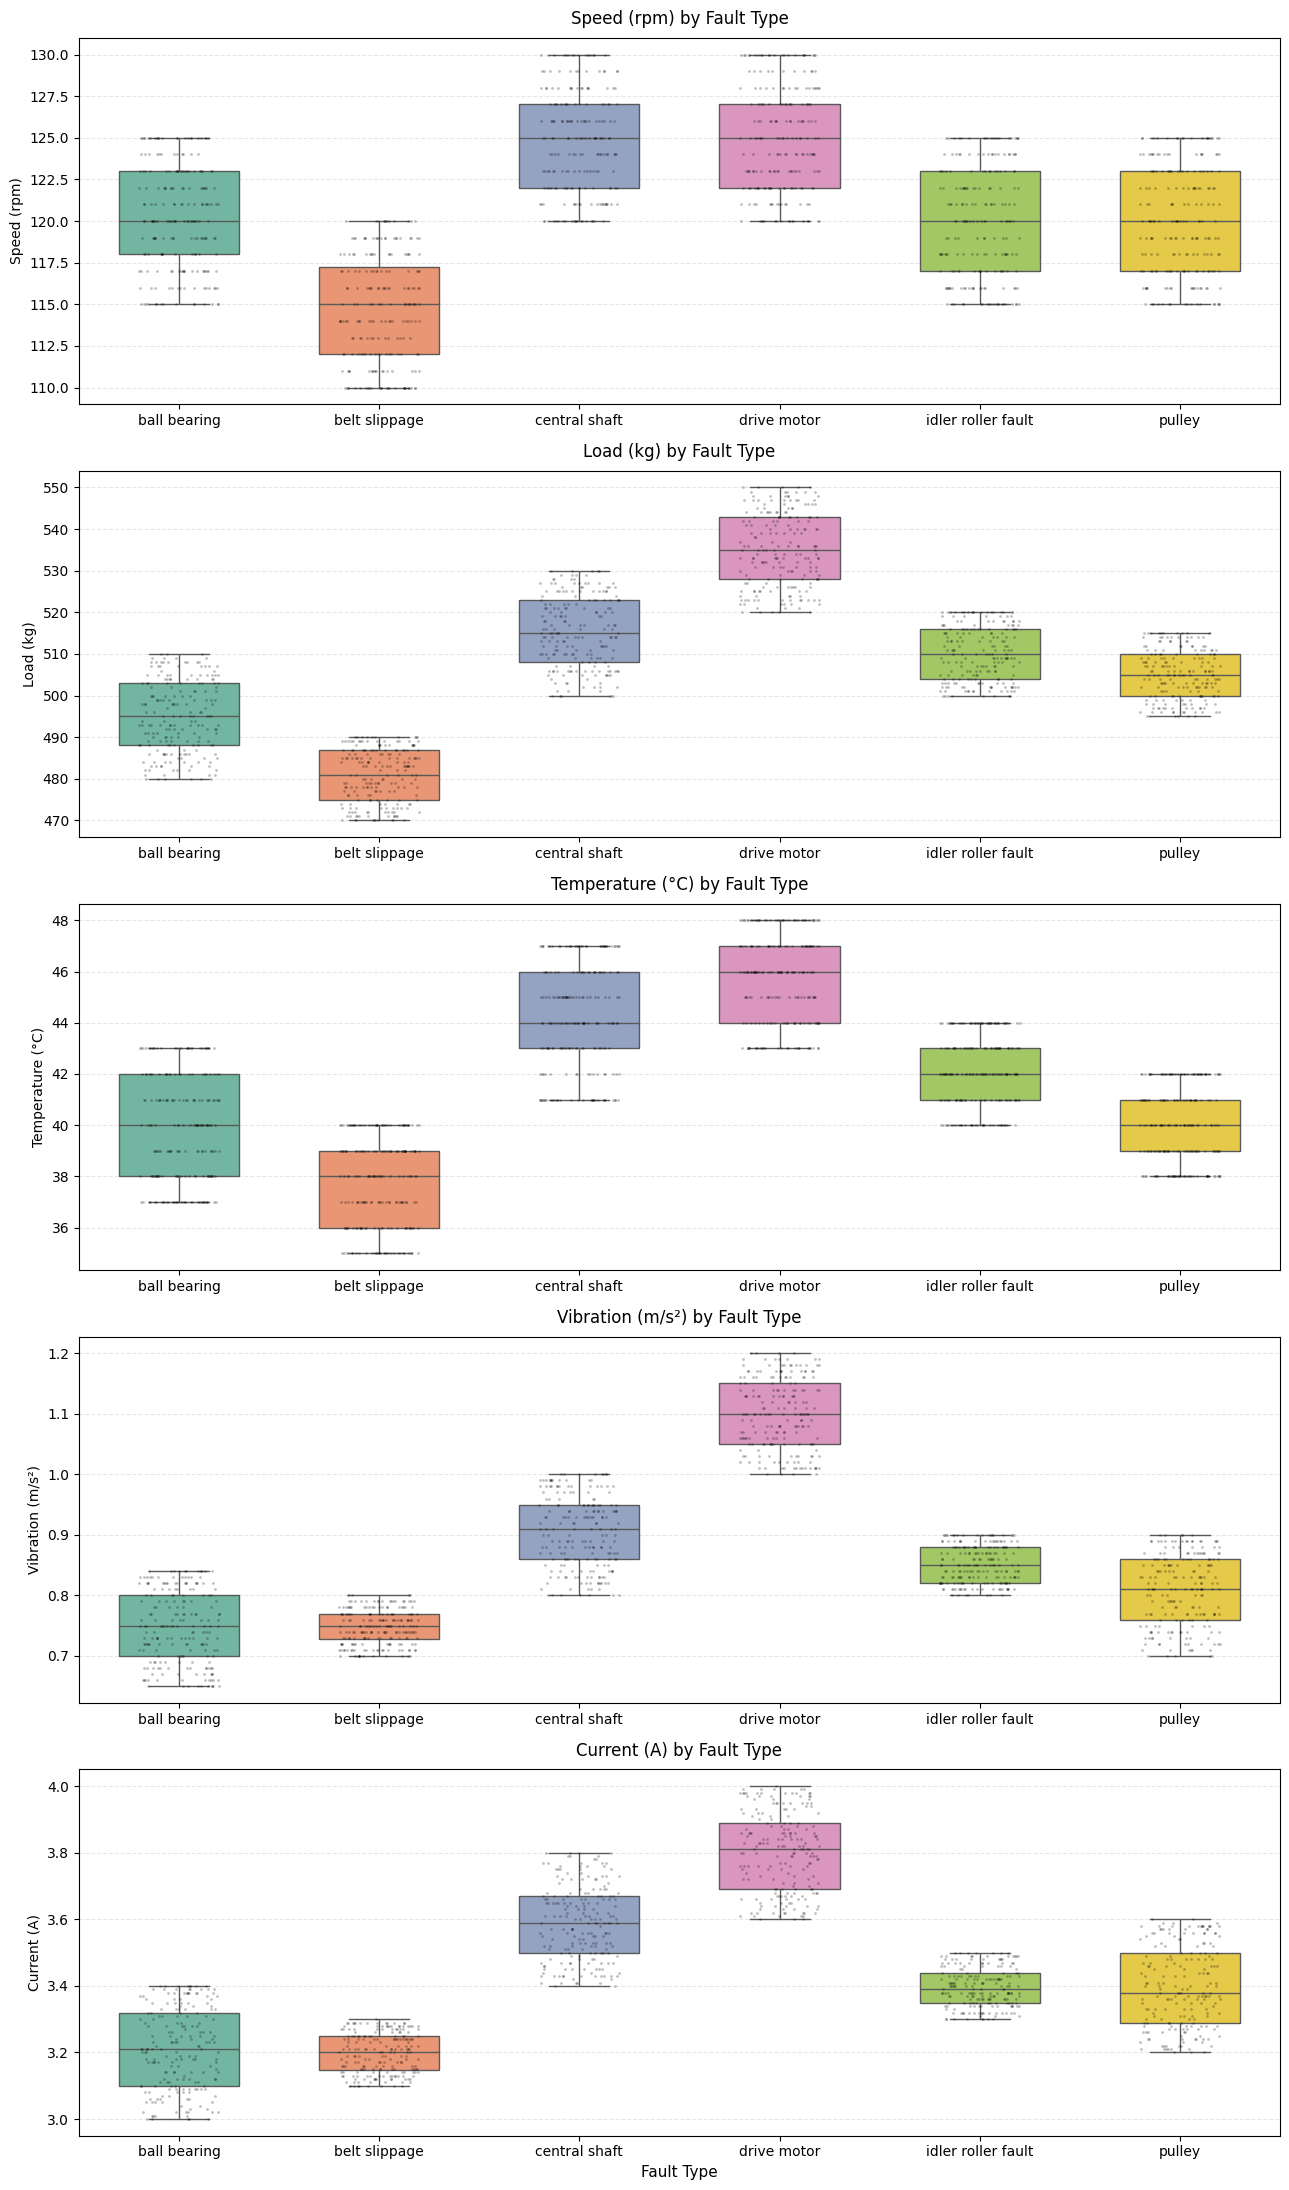

In [14]:
# Box-plots of features by fault type
fault_order = sorted(data['fault'].unique())

def fault_boxplots(data, features_labels, fault_order):
    _, axes = plt.subplots(5, 1, figsize=(13, 22))
    for ax, (col, label) in zip(axes, features_labels.items()):
        sns.boxplot(
            data=data,
            x='fault',
            y=col,
            hue='fault',
            order=fault_order,
            hue_order=fault_order,
            ax=ax,
            palette='Set2',
            width=0.6,
            fliersize=0,
            legend=False
        )

        sns.stripplot(
            data=data,
            x='fault',
            y=col,
            order=fault_order,
            ax=ax,
            color='black',
            alpha=0.25,
            size=2,
            jitter=0.2
        )

        ax.set_title(f'{label} by Fault Type', fontsize=12, pad=10)
        ax.set_xlabel('')
        ax.set_ylabel(label)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)

    axes[-1].set_xlabel('Fault Type', fontsize=11)

    plt.tight_layout()
    plt.show()

fault_boxplots(data, feature_labels, fault_order)

The boxplots show that the sensor variables exhibit distinct distributions across fault types, suggesting that the dataset contains meaningful discriminatory patterns. In particular, drive motor and central shaft faults tend to present higher values of load, temperature, vibration, and current, whereas belt slippage is generally associated with lower speed, load, and temperature values. By contrast, ball bearing, idler roller fault, and pulley display a greater degree of overlap in several variables, indicating that these classes may be more difficult to distinguish using single features alone. Overall, the figure suggests that the classification problem is structured and that the combination of multiple variables will likely improve fault separation.


## 3. Feature analysis and dimensionality reduction

This section investigates the predictive relevance and relationships of the input variables. Correlation analysis is used to identify potential redundancy among features, while ANOVA and graphical comparisons help evaluate how strongly each variable differs across fault classes. Principal Component Analysis (PCA) is then applied to reduce the dimensionality of the feature space and to visualize the data in a more compact form. The goal is not only to simplify the representation of the dataset, but also to assess whether this reduction preserves enough information for accurate classification.

In [15]:
# Sacling features using StandardScaler
from sklearn.preprocessing import StandardScaler

X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

data_scaled = pd.DataFrame(X_scaled, columns=features)
data_scaled['fault'] = data['fault']

    PC  Explained Variance Ratio  Cumulative Variance
0  PC1                  0.753668             0.753668
1  PC2                  0.105520             0.859188
2  PC3                  0.062514             0.921702
3  PC4                  0.040908             0.962610
4  PC5                  0.037390             1.000000
Number of components to explain at least 90% variance: 3
Number of components to explain at least 95% variance: 4


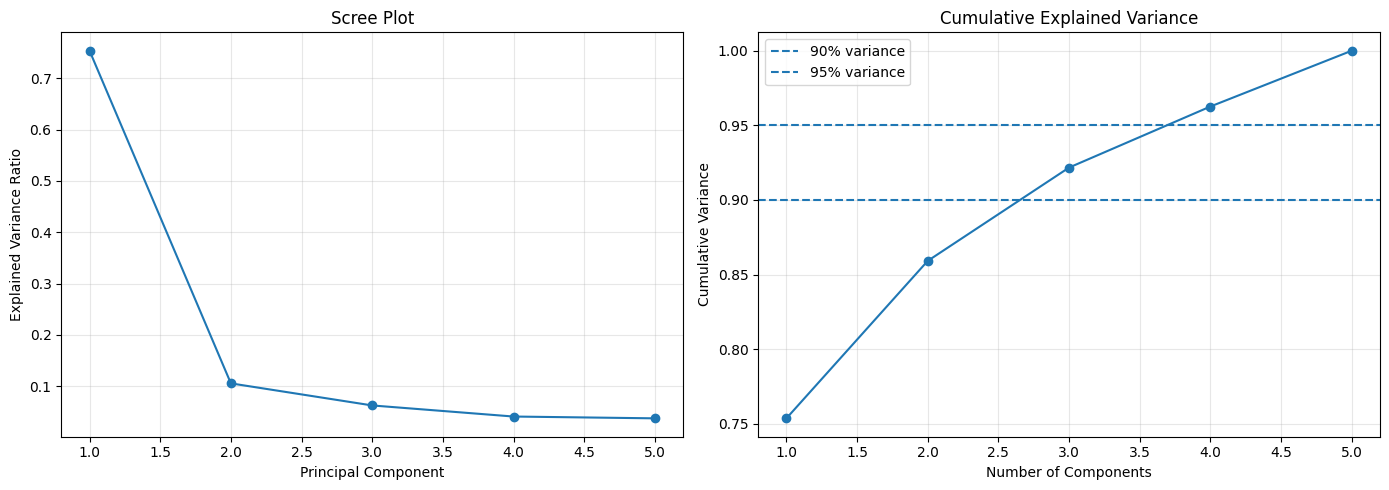

In [16]:
# Apply PCA
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

# Explained variance ratio and cumulative variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

pca_summary = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, len(explained_variance_ratio) + 1)],
    'Explained Variance Ratio': explained_variance_ratio,
    'Cumulative Variance': cumulative_variance
})

print(pca_summary)

# Number of components for different thresholds
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f'Number of components to explain at least 90% variance: {n_90}')
print(f'Number of components to explain at least 95% variance: {n_95}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker='o'
)
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(alpha=0.3)

# Accumulated variance plot
axes[1].plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
axes[1].axhline(0.90, linestyle='--', label='90% variance')
axes[1].axhline(0.95, linestyle='--', label='95% variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The PCA results show that the first principal component explains 75.37% of the total variance, while the second adds 10.55%, so the first two components together retain 85.92% of the overall variability. This indicates that most of the information in the dataset is concentrated in a low-dimensional space. Although three components would be required to exceed the 90% threshold, retaining two principal components provides a reasonable trade-off between dimensionality reduction and information preservation. Therefore, two components were selected as they capture the main structure of the data while allowing an efficient and interpretable two-dimensional representation.

In [17]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features))],
    index=features
)

print(loadings.round(3))

                 PC1    PC2    PC3    PC4    PC5
speed_rpm      0.385  0.906 -0.122 -0.101  0.078
load_kg        0.471 -0.101 -0.120  0.821 -0.282
temperature_c  0.446 -0.088  0.881 -0.126  0.037
vibration_ms2  0.463 -0.314 -0.311 -0.087  0.764
current_a      0.465 -0.251 -0.313 -0.541 -0.574


The PCA loadings show that the first principal component is positively associated with all variables, with the strongest contributions coming from load, current, vibration, and temperature. This suggests that PC1 captures a general pattern of operating intensity or fault severity, where higher values correspond to more demanding operating conditions. By contrast, the second principal component is dominated by speed, indicating that PC2 mainly represents variation related to rotational speed rather than the overall intensity captured by PC1. Therefore, the two-dimensional PCA representation can be interpreted as a combination of overall operational severity and speed-related variation.

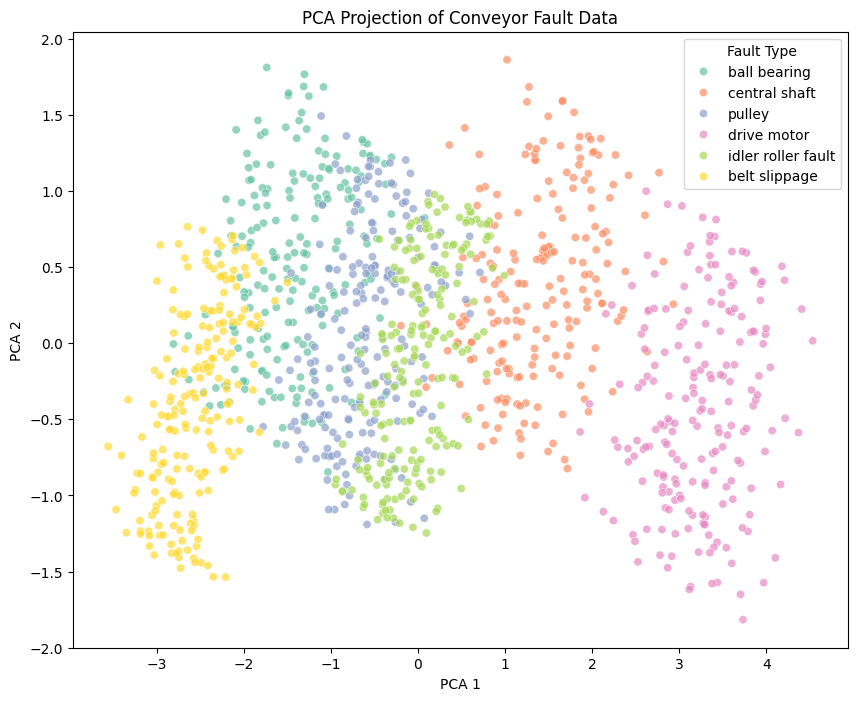

In [18]:
# Representation of data in the PCA space
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:,1], hue=data['fault'], alpha=0.7, palette='Set2')
plt.legend(title='Fault Type')
plt.title('PCA Projection of Conveyor Fault Data')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

It seems that using principal components help to differentiate more among faults that the initial features although there are regios where faults overlap, specially pulley fault as it overlaps totally with ball bearing and idler roller fault. Moreover, ball bearing also overlaps with belt slippage over a fairly large region.

In [19]:
data['fault'].unique()

array(['ball bearing', 'central shaft', 'pulley', 'drive motor',
       'idler roller fault', 'belt slippage'], dtype=object)

## 4. Modeling strategy

The modeling stage is designed to compare several supervised learning approaches under a consistent workflow. After splitting the data into training and test sets, the input features are scaled and, when appropriate, transformed through PCA. Three different classifiers are considered: Random Forest, XGBoost, and a Neural Network. Hyperparameter tuning is performed using randomized search in order to improve each model configuration without relying on arbitrary parameter choices. This strategy allows a fair comparison between models trained on the original feature space and on the PCA-based representation.

Throughout this analysis, we retain both the raw data and the PCA-transformed data, and we evaluate several algorithms on each representation

In [20]:
# Split data into training and testing sets stratifed by fault type
from sklearn.model_selection import train_test_split
 
X = data[features]
y = data['fault']

label_map = {
    'belt slippage': 0,
    'ball bearing': 1,
    'idler roller fault': 2,
    'pulley': 3,
    'drive motor': 4,
    'central shaft': 5
}

y = y.map(label_map)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply StandardScaler to training and testing data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((967, 5), (242, 5), (967,), (242,))

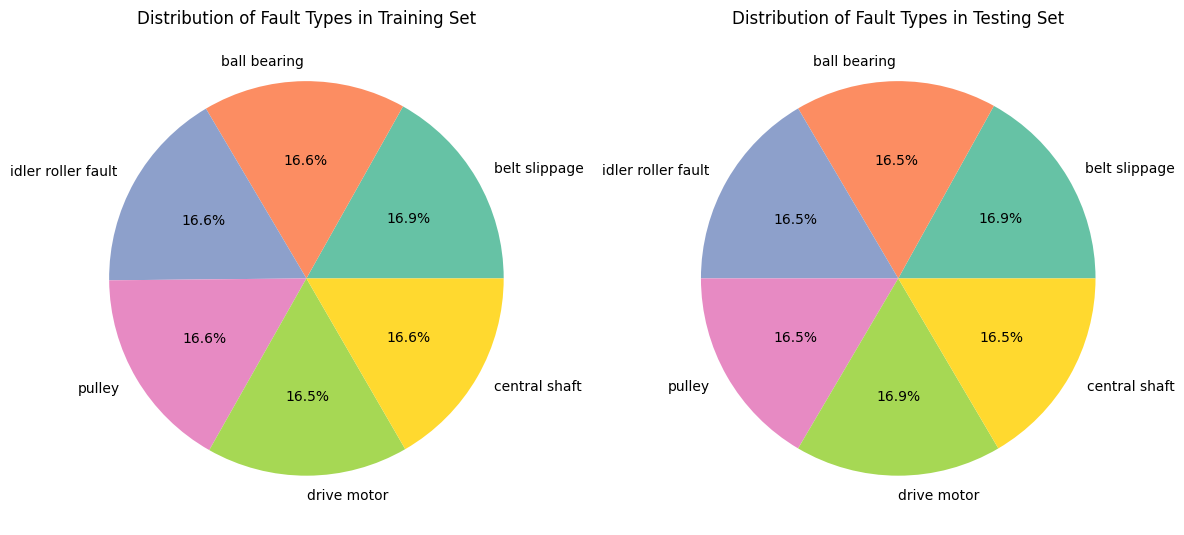

In [21]:
inv_map = {v: k for k, v in label_map.items()}

codes = sorted(set(y_train.unique()) | set(y_test.unique()))
label_names = [inv_map[i] for i in codes]

train_counts = y_train.value_counts().reindex(codes, fill_value=0)
test_counts = y_test.value_counts().reindex(codes, fill_value=0)

colors = sns.color_palette('Set2', n_colors=len(codes))

plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.pie(train_counts, labels=label_names, autopct='%1.1f%%', colors=colors)
plt.title('Distribution of Fault Types in Training Set')

plt.subplot(1, 2, 2)
plt.pie(test_counts, labels=label_names, autopct='%1.1f%%', colors=colors)
plt.title('Distribution of Fault Types in Testing Set')

plt.show()

In [22]:
#  Prepare models: XGBoost, Random Forest, Neural Network using RandomizedSearchCV for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Import libraries for saving and loading models
import joblib
from tensorflow.keras.models import load_model

# param_grid_rf = {
#     'n_estimators': np.arange(100, 1001, 100),
#     'max_depth': [None, 10, 20],
#     'min_samples_split': np.arange(2, 11, 2),
#     'min_samples_leaf': np.arange(2, 9, 2),
#     'max_features': ['sqrt', 'log2', None],
#     'bootstrap': [True, False]
# }

# rf = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), 
#                         param_distributions=param_grid_rf, 
#                         n_iter=50, 
#                         cv=5, 
#                         verbose=2, 
#                         random_state=42, 
#                         n_jobs=-1)

# rf.fit(X_train, y_train)
# print("Best Hyperparameters for Random Forest:")
# print(rf.best_params_)
# print("Best Cross-Validation Score for Random Forest:")
# print(rf.best_score_)

# # Save Random Forest model
# joblib.dump(rf, '../models/rf_model.pkl')

In [23]:
from xgboost import XGBClassifier

# param_grid_xgb = {
#     'n_estimators': np.arange(100, 1001, 100),
#     'max_depth': np.arange(2, 11, 2),
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0]
# }

# xgb = RandomizedSearchCV(estimator=XGBClassifier(random_state=42), 
#                         param_distributions=param_grid_xgb, 
#                         n_iter=50, 
#                         cv=5, 
#                         verbose=2, 
#                         random_state=42, 
#                         n_jobs=-1)

# xgb.fit(X_train, y_train)
# print("Best Hyperparameters for XGBoost:")
# print(xgb.best_params_)
# print("Best Cross-Validation Score for XGBoost:")
# print(xgb.best_score_)

# # Save XGBoost model
# joblib.dump(xgb, '../models/xgb_model.pkl')

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(n_features, n_hidden=1, n_neurons=32, learning_rate=0.001, dropout_rate=0.0):

    model = Sequential()
    model.add(Input(shape=(n_features,)))
    model.add(Dense(n_neurons, activation="relu"))
    model.add(Dropout(dropout_rate))
    for i in range(n_hidden - 1):
        model.add(Dense(n_neurons * (i+1), activation="relu"))
    model.add(Dense(6, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [25]:
from scikeras.wrappers import KerasClassifier

# keras_clf = KerasClassifier(
#     model=build_model,
#     model__n_features=X_train.shape[1],
#     epochs=50,
#     batch_size=32,
#     verbose=0
# )

# param_grid_nn = {
#     "model__n_hidden": [1, 2, 3],
#     "model__n_neurons": [16, 32],
#     "model__learning_rate": [1e-3, 1e-4, 5e-4],
#     "model__dropout_rate": [0.0, 0.2, 0.4],
#     "batch_size": [16, 32, 64],
#     "epochs": [20, 50, 100]
# }

# nn = RandomizedSearchCV(
#     estimator=keras_clf,
#     param_distributions=param_grid_nn,
#     n_iter=15,
#     scoring="accuracy",  
#     cv=5,
#     random_state=42,
#     n_jobs=1
# )

# nn.fit(X_train, y_train)
# print("Best Hyperparameters for Neural Network:")
# print(nn.best_params_)
# print("Best Cross-Validation Score for Neural Network:")
# print(nn.best_score_)

# # Save Neural Network model
# nn.best_estimator_.model_.save('../models/nn_model.h5')


In [26]:
# Train models with PCA components
# rf_pca = RandomForestClassifier(**rf.best_params_, random_state=42)
# rf_pca.fit(X_train_pca, y_train)

# xgb_pca = XGBClassifier(**xgb.best_params_, random_state=42)
# xgb_pca.fit(X_train_pca, y_train)

# nn_pca = KerasClassifier(
#     model=build_model,
#     model__n_features=X_train_pca.shape[1],
#     **nn.best_params_,
#     verbose=0
# )
# nn_pca.fit(X_train_pca, y_train)

# joblib.dump(rf_pca, 'rf_model_pca.pkl')
# joblib.dump(xgb_pca, 'xgb_model_pca.pkl')
# nn_pca.model_.save('../models/nn_model_pca.h5')


In [28]:
# Load the saved models (run this cell when reinitializing the notebook)
rf= joblib.load('../models/rf_model.pkl')
xgb = joblib.load('../models/xgb_model.pkl')
nn = load_model('../models/nn_model.h5')

rf_pca = joblib.load('../models/rf_model_pca.pkl')
xgb_pca = joblib.load('../models/xgb_model_pca.pkl')
nn_pca = load_model('../models/nn_model_pca.h5')

In [29]:
# Friendly summary of saved models: key hyperparameters + training metric
from sklearn.metrics import accuracy_score

def _format_value(value):
    if isinstance(value, float):
        return f"{value:.4f}"
    return str(value)

def _resolve_estimator(model):
    return model.best_estimator_ if hasattr(model, 'best_estimator_') else model

def _safe_pick(params, preferred_keys):
    selected = {}
    for key in preferred_keys:
        if key in params:
            selected[key] = params[key]
        elif f'estimator__{key}' in params:
            selected[key] = params[f'estimator__{key}']
    return selected

def _print_block(title, params, train_accuracy, notes=None):
    print(f"\n{'=' * 70}")
    print(f"{title:^70}")
    print(f"{'=' * 70}")
    print(f"Train accuracy: {train_accuracy:.4f}")
    print("Key hyperparameters:")
    for key, value in params.items():
        print(f"  - {key}: {_format_value(value)}")
    if notes:
        print("Notes:")
        for note in notes:
            print(f"  - {note}")

def _keras_summary(model):
    dense_units = []
    dropout_rates = []
    for layer in model.layers:
        units = getattr(layer, 'units', None)
        if units is not None:
            dense_units.append(units)
        rate = getattr(layer, 'rate', None)
        if rate is not None:
            dropout_rates.append(rate)

    learning_rate = model.optimizer.learning_rate
    if hasattr(learning_rate, 'numpy'):
        learning_rate = float(learning_rate.numpy())

    hidden_units = dense_units[:-1] if len(dense_units) > 1 else dense_units

    return {
        'n_hidden_layers': max(len(hidden_units), 0),
        'hidden_units': hidden_units,
        'dropout_rates': dropout_rates if dropout_rates else [0.0],
        'learning_rate': learning_rate,
        'output_units': dense_units[-1] if dense_units else 'N/A',
        'loss': model.loss
    }

rf_model = _resolve_estimator(rf)
xgb_model = _resolve_estimator(xgb)
rf_pca_model = _resolve_estimator(rf_pca)
xgb_pca_model = _resolve_estimator(xgb_pca)

raw_models = {
    'Random Forest - raw features': {
        'model': rf_model,
        'X_train_used': X_train,
        'params': _safe_pick(rf_model.get_params(), ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'bootstrap', 'random_state']),
        'notes': ['Loaded from search object.' if hasattr(rf, 'best_estimator_') else 'Loaded as final estimator.']
    },
    'XGBoost - raw features': {
        'model': xgb_model,
        'X_train_used': X_train,
        'params': _safe_pick(xgb_model.get_params(), ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'objective', 'random_state']),
        'notes': ['Loaded from search object.' if hasattr(xgb, 'best_estimator_') else 'Loaded as final estimator.']
    },
    'Neural Network - raw features': {
        'model': nn,
        'X_train_used': X_train,
        'params': _keras_summary(nn),
        'notes': ['Train accuracy recalculated from the loaded model.', 'The saved .h5 model does not keep the original search metadata such as epochs sampled or CV score.']
    }
}

pca_models = {
    'Random Forest - PCA': {
        'model': rf_pca_model,
        'X_train_used': X_train_pca,
        'params': _safe_pick(rf_pca_model.get_params(), ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'bootstrap', 'random_state']),
        'notes': ['Loaded from search object.' if hasattr(rf_pca, 'best_estimator_') else 'Loaded as final estimator.']
    },
    'XGBoost - PCA': {
        'model': xgb_pca_model,
        'X_train_used': X_train_pca,
        'params': _safe_pick(xgb_pca_model.get_params(), ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'objective', 'random_state']),
        'notes': ['Loaded from search object.' if hasattr(xgb_pca, 'best_estimator_') else 'Loaded as final estimator.']
    },
    'Neural Network - PCA': {
        'model': nn_pca,
        'X_train_used': X_train_pca,
        'params': _keras_summary(nn_pca),
        'notes': ['Train accuracy recalculated from the loaded model.', 'The saved .h5 model does not keep the original search metadata such as epochs sampled or CV score.']
    }
}

for title, info in {**raw_models, **pca_models}.items():
    model = info['model']
    X_used = info['X_train_used']

    if 'Neural Network' in title:
        y_pred_train = model.predict(X_used, verbose=0).argmax(axis=1)
    else:
        y_pred_train = model.predict(X_used)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    _print_block(title, info['params'], train_accuracy, info.get('notes'))



                     Random Forest - raw features                     
Train accuracy: 0.9669
Key hyperparameters:
  - n_estimators: 300
  - max_depth: None
  - min_samples_split: 8
  - min_samples_leaf: 2
  - max_features: sqrt
  - bootstrap: True
  - random_state: 42
Notes:
  - Loaded as final estimator.

                        XGBoost - raw features                        
Train accuracy: 0.9411
Key hyperparameters:
  - n_estimators: 200
  - max_depth: 6
  - learning_rate: 0.0100
  - subsample: 1.0000
  - colsample_bytree: 0.6000
  - objective: multi:softprob
  - random_state: 42
Notes:
  - Loaded from search object.

                    Neural Network - raw features                     
Train accuracy: 0.8728
Key hyperparameters:
  - n_hidden_layers: 3
  - hidden_units: [16, 16, 32]
  - dropout_rates: [0.0]
  - learning_rate: 0.0005
  - output_units: 6
  - loss: <function sparse_categorical_crossentropy at 0x00000192B025BF60>
Notes:
  - Train accuracy recalculated from the loaded

## 5. Model evaluation

Model performance is assessed on the held-out test set using several complementary metrics. Accuracy provides an overall measure of classification performance, while precision, recall, and F1-score offer a more detailed view of how well each fault category is identified. Confusion matrices are also examined to highlight the most frequent misclassifications and to understand which classes are more difficult to separate. This evaluation framework makes it possible to compare not only the overall predictive quality of the models, but also the consistency of their behavior across individual fault types.

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "macro_precision": "precision_macro",
    "macro_recall": "recall_macro"
}

In [54]:
cv_results = []

models= {
    "RF raw": rf,
    "XGB raw": xgb,
    "RF PCA": rf_pca,
    "XGB PCA": xgb_pca
}

for name, model in models.items():
    X_cv = X_train if "raw" in name else X_train_pca
    scores = cross_validate(
        model, X_cv, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_precision_mean": scores["test_macro_precision"].mean(),
        "cv_macro_recall_mean": scores["test_macro_recall"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_macro_f1_mean", ascending=False)
cv_results_df

,model,cv_accuracy_mean,cv_macro_f1_mean,cv_macro_precision_mean,cv_macro_recall_mean
1,XGB raw,0.937941,0.937351,0.942835,0.937847
0,RF raw,0.911052,0.908443,0.914889,0.910890
2,RF PCA,0.807612,0.806057,0.807628,0.807449
3,XGB PCA,0.771444,0.769652,0.772700,0.771338


The cross-validation results confirm that XGBoost trained on the original feature space is the most robust model, achieving the highest mean values in accuracy, macro F1, precision, and recall. Random Forest on the raw features also performs well, but consistently below XGBoost. In contrast, both PCA-based versions show a clear drop in performance, especially XGBoost PCA, which suggests that reducing the data to two principal components removes part of the discriminative information needed for fault classification. Overall, these results reinforce the conclusion that the original sensor variables contain richer predictive structure than the reduced PCA representation.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

RF raw
Accuracy: 0.8966942148760331
                    precision    recall  f1-score   support

     belt slippage       0.91      1.00      0.95        41
      ball bearing       0.94      0.72      0.82        40
idler roller fault       0.80      1.00      0.89        40
            pulley       0.83      0.75      0.79        40
       drive motor       1.00      0.98      0.99        41
     central shaft       0.93      0.93      0.93        40

          accuracy                           0.90       242
         macro avg       0.90      0.90      0.89       242
      weighted avg       0.90      0.90      0.89       242



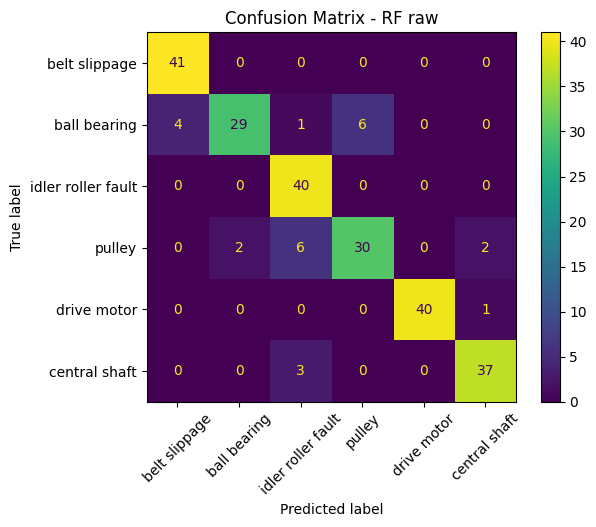


XGB raw
Accuracy: 0.9049586776859504
                    precision    recall  f1-score   support

     belt slippage       0.91      1.00      0.95        41
      ball bearing       1.00      0.70      0.82        40
idler roller fault       0.80      1.00      0.89        40
            pulley       0.82      0.80      0.81        40
       drive motor       1.00      1.00      1.00        41
     central shaft       0.95      0.93      0.94        40

          accuracy                           0.90       242
         macro avg       0.91      0.90      0.90       242
      weighted avg       0.91      0.90      0.90       242



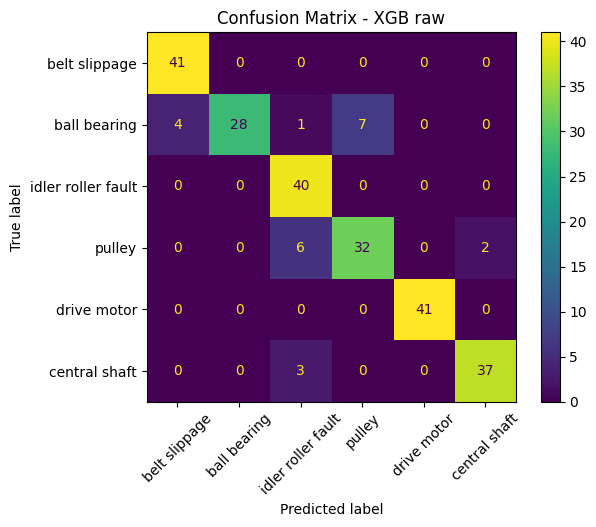


NN raw
Accuracy: 0.859504132231405
                    precision    recall  f1-score   support

     belt slippage       0.89      0.98      0.93        41
      ball bearing       0.81      0.72      0.76        40
idler roller fault       0.77      0.93      0.84        40
            pulley       0.82      0.68      0.74        40
       drive motor       0.98      0.98      0.98        41
     central shaft       0.90      0.88      0.89        40

          accuracy                           0.86       242
         macro avg       0.86      0.86      0.86       242
      weighted avg       0.86      0.86      0.86       242



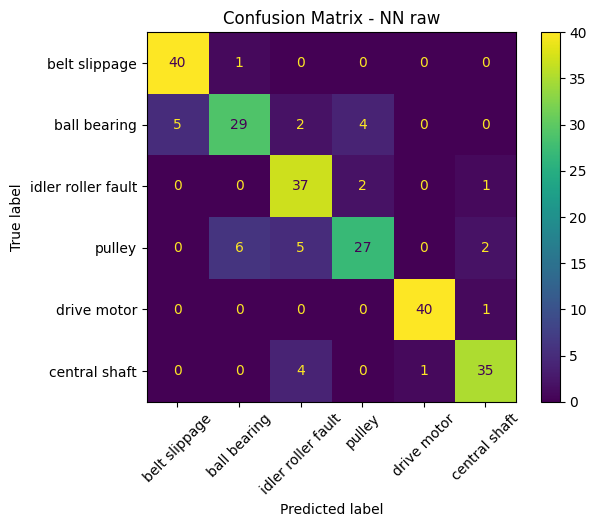


RF PCA
Accuracy: 0.8099173553719008
                    precision    recall  f1-score   support

     belt slippage       0.80      0.98      0.88        41
      ball bearing       0.79      0.55      0.65        40
idler roller fault       0.74      0.88      0.80        40
            pulley       0.70      0.65      0.68        40
       drive motor       0.97      0.90      0.94        41
     central shaft       0.86      0.90      0.88        40

          accuracy                           0.81       242
         macro avg       0.81      0.81      0.80       242
      weighted avg       0.81      0.81      0.80       242



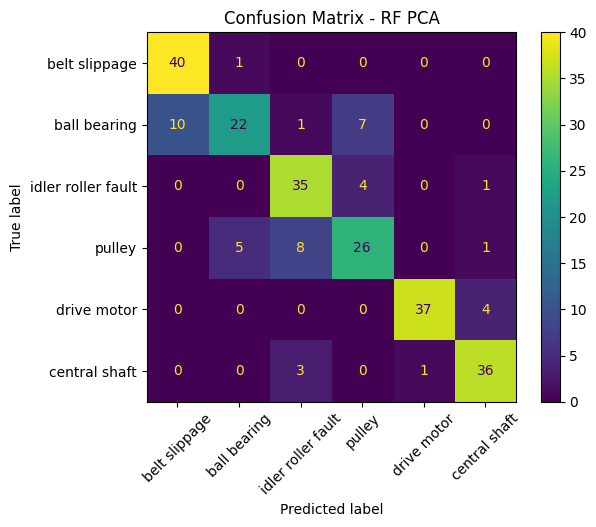


XGB PCA
Accuracy: 0.7520661157024794
                    precision    recall  f1-score   support

     belt slippage       0.80      0.98      0.88        41
      ball bearing       0.69      0.50      0.58        40
idler roller fault       0.63      0.78      0.70        40
            pulley       0.57      0.50      0.53        40
       drive motor       0.97      0.88      0.92        41
     central shaft       0.83      0.88      0.85        40

          accuracy                           0.75       242
         macro avg       0.75      0.75      0.74       242
      weighted avg       0.75      0.75      0.75       242



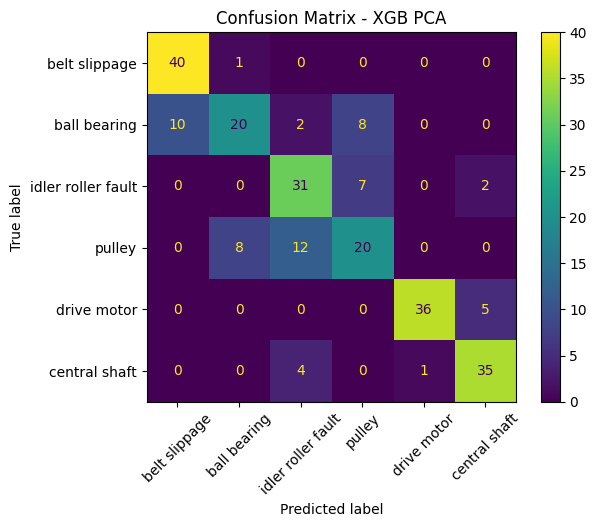


NN PCA
Accuracy: 0.7851239669421488
                    precision    recall  f1-score   support

     belt slippage       0.78      0.98      0.87        41
      ball bearing       0.73      0.55      0.63        40
idler roller fault       0.68      0.80      0.74        40
            pulley       0.70      0.57      0.63        40
       drive motor       0.97      0.93      0.95        41
     central shaft       0.83      0.88      0.85        40

          accuracy                           0.79       242
         macro avg       0.78      0.78      0.78       242
      weighted avg       0.78      0.79      0.78       242



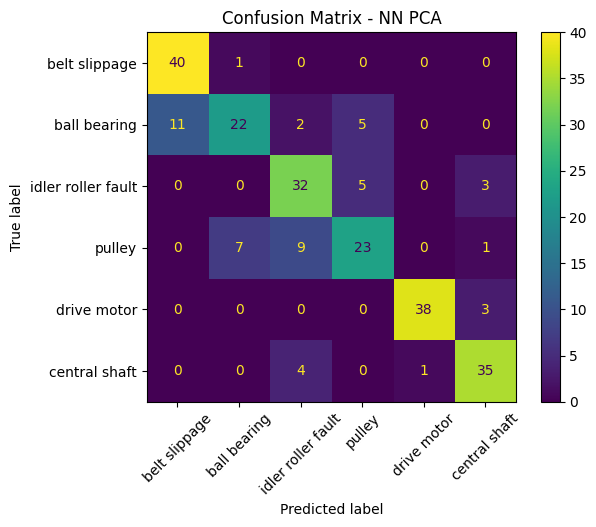

In [32]:
# Evaluate models on test set
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_nn = nn.predict(X_test).argmax(axis=1)

y_pred_rf_pca = rf_pca.predict(X_test_pca)
y_pred_xgb_pca = xgb_pca.predict(X_test_pca)
y_pred_nn_pca = nn_pca.predict(X_test_pca).argmax(axis=1)

models_predictions = {
    "RF raw": y_pred_rf,
    "XGB raw": y_pred_xgb,
    "NN raw": y_pred_nn,
    "RF PCA": y_pred_rf_pca,
    "XGB PCA": y_pred_xgb_pca,
    "NN PCA": y_pred_nn_pca
}

for name, y_pred in models_predictions.items():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=label_names))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(xticks_rotation=45)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

The classification results show that the best performance is achieved using the original standardized features rather than the PCA-transformed ones. XGBoost on the raw data obtained the highest accuracy, at approximately 90.5%, followed closely by Random Forest at 89.7%, while the neural network achieved 85.1%. In contrast, all models performed worse when trained on only the first two principal components: Random Forest reached 81.0%, the neural network 78.5%, and XGBoost 75.2%. These results indicate that although PCA preserves most of the variance, it also removes part of the information needed to distinguish between similar faults. Therefore, for this classification task, dimensionality reduction to two components is more useful for interpretation than for maximizing predictive performance.

## 6. Interpretability and robustness

Beyond predictive performance, this project also evaluates how reliable and interpretable the resulting models are. Feature importance analysis is used to identify which variables contribute most strongly to the classification task, while the ablation study helps measure the impact of removing or restricting features. These analyses are useful to verify whether the model relies on meaningful physical patterns rather than on arbitrary correlations. In this way, the project not only identifies the best-performing model, but also provides evidence regarding the stability and practical relevance of its predictions.

In [ ]:
# Analyze misclassifications for the best performing model (XGBoost with raw features in this case)
errors_df = pd.DataFrame({
    "true": y_test,
    "pred": y_pred_xgb
})

errors_df = errors_df[errors_df["true"] != errors_df["pred"]]

error_pairs = (
    errors_df.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs["true_label"] = error_pairs["true"].map(inv_map)
error_pairs["pred_label"] = error_pairs["pred"].map(inv_map)

error_pairs[["true_label", "pred_label", "count"]]

,true_label,pred_label,count
2,ball bearing,pulley,7
3,pulley,idler roller fault,6
0,ball bearing,belt slippage,4
5,central shaft,idler roller fault,3
4,pulley,central shaft,2
1,ball bearing,idler roller fault,1


In [52]:
# Detailed analysis of misclassified samples for XGBoost with raw features
X_test_df = pd.DataFrame(scaler.inverse_transform(X_test), columns=features)
X_test_df["true"] = y_test.values
X_test_df["pred"] = y_pred_xgb

misclassified = X_test_df[X_test_df["true"] != X_test_df["pred"]].copy()
misclassified["true_label"] = misclassified["true"].map(inv_map)
misclassified["pred_label"] = misclassified["pred"].map(inv_map)
misclassified.drop(columns=["true", "pred"], inplace=True)

misclassified.head(20)

,speed_rpm,load_kg,temperature_c,vibration_ms2,current_a,true_label,pred_label
20,120.0,501.0,42.0,0.85,3.56,pulley,central shaft
23,115.0,490.0,37.0,0.73,3.11,ball bearing,belt slippage
24,119.0,504.0,40.0,0.89,3.35,pulley,idler roller fault
38,119.0,501.0,40.0,0.74,3.35,ball bearing,pulley
46,118.0,509.0,43.0,0.81,3.32,ball bearing,idler roller fault
50,125.0,508.0,40.0,0.83,3.21,ball bearing,pulley
55,115.0,484.0,40.0,0.80,3.21,ball bearing,belt slippage
57,125.0,507.0,38.0,0.76,3.36,ball bearing,pulley
71,117.0,504.0,41.0,0.84,3.38,pulley,idler roller fault
88,117.0,500.0,40.0,0.87,3.37,pulley,idler roller fault


The error analysis shows that the model’s mistakes are concentrated in a few specific class pairs rather than being randomly distributed. The most frequent confusions are **ball bearing → pulley**, **pulley → idler roller fault**, and **ball bearing → belt slippage**, which suggests that these fault types have partially overlapping sensor patterns. The misclassified samples tend to appear within very similar ranges of speed, load, temperature, vibration, and current, indicating that the decision boundaries between these classes are narrow. Overall, the model captures the general structure of the problem well, but it struggles with faults that share similar operational signatures, especially **ball bearing** and **pulley**.


vibration_ms2    0.273140
current_a        0.151446
temperature_c    0.125620
load_kg          0.103926
speed_rpm        0.037190
dtype: float64


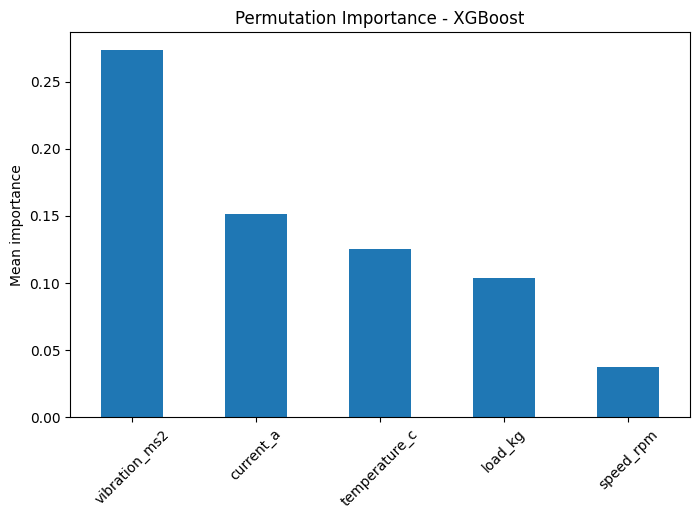

In [ ]:
# Permutation importance for XGBoost with raw features
from sklearn.inspection import permutation_importance

best_xgb_model = xgb.best_estimator_
perm = permutation_importance(
    best_xgb_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

perm_importances = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

print(perm_importances)

plt.figure(figsize=(8,5))
perm_importances.plot(kind='bar')
plt.title('Permutation Importance - XGBoost')
plt.ylabel('Mean importance')
plt.xticks(rotation=45)
plt.show()

Across models, drive motor and belt slippage are the easiest fault types to classify, with very high recall and F1-scores. By contrast, ball bearing and pulley faults are the most challenging categories, as they tend to be confused more frequently with other classes. This pattern is consistent with the exploratory analysis and PCA visualizations, where these classes showed more overlap. Therefore, the classification results are coherent with the structure previously observed in the feature space.

In [38]:
from sklearn.metrics import f1_score

feature_sets = {
    "all_features": ['speed_rpm', 'load_kg', 'temperature_c', 'vibration_ms2', 'current_a'],
    "top_3": ['load_kg', 'vibration_ms2', 'current_a'],
    "without_speed": ['load_kg', 'temperature_c', 'vibration_ms2', 'current_a'],
    "only_vibration": ['vibration_ms2'],
    "only_current": ['current_a']
}

results_ablation = []

for name, cols in feature_sets.items():
    X_sub = data[cols]
    y_sub = data['fault'].map(label_map)

    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    scaler_sub = StandardScaler()
    X_train_sub = scaler_sub.fit_transform(X_train_sub)
    X_test_sub = scaler_sub.transform(X_test_sub)

    model = XGBClassifier(**xgb.best_params_)
    model.fit(X_train_sub, y_train_sub)
    y_pred_sub = model.predict(X_test_sub)

    results_ablation.append({
        "feature_set": name,
        "accuracy": accuracy_score(y_test_sub, y_pred_sub),
        "macro_f1": f1_score(y_test_sub, y_pred_sub, average='macro')
    })

ablation_df = pd.DataFrame(results_ablation).sort_values(by="macro_f1", ascending=False)
print(ablation_df)

      feature_set  accuracy  macro_f1
0    all_features  0.904959  0.902124
2   without_speed  0.904959  0.902028
1           top_3  0.830579  0.825228
3  only_vibration  0.623967  0.573365
4    only_current  0.561983  0.523995


Permutation importance based on the best XGBoost model confirms that vibration is the most influential feature by a clear margin, followed by current, temperature, and load, while speed contributes the least. This is fully aligned with the ANOVA results and with the domain intuition that mechanical faults in conveyor systems are especially reflected in vibration behavior and electrical response. The consistency between statistical analysis and model-based importance strengthens the reliability of the conclusions.

## 7. Limitations, future work and final recommendation

Although the results are strong, the project has some limitations that should be acknowledged. The dataset is relatively small, balanced, and clean, which makes the task more controlled than many real industrial applications. In addition, the target only includes fault categories, so the project does not address the earlier and equally important task of distinguishing healthy from faulty operating conditions. Future work could include testing the models on additional datasets, exploring more advanced explainability techniques, and extending the problem toward anomaly detection or predictive maintenance settings with temporal data. Based on the results obtained here, the final recommendation is to prioritize tree-based ensemble models trained on the original feature set, since they achieve the best balance between predictive performance and interpretability.